In [1]:
import cooler
import cooltools
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score
from ggner_3d.cm import prepare_view_df, CLR_CONNS, get_expected_cis_df
import pandas as pd
import numpy as np
from coolpuppy import coolpup
from ggner_3d import plotting
plotting.update_rcparams()

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

resolution = 10_000
window = 500_000 # 500_000 or 100_000

u2os_clr = CLR_CONNS(resolution=resolution)

In [2]:
clr_dict = {
    'WTnoUV': u2os_clr['WTnoUV'],
    'XPCnoUV': u2os_clr['XPCnoUV'],
    'WT3h': u2os_clr['WT3h'],
    'pol2_control': cooler.Cooler('/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394172_control_mergeRep_500bp.mcool::/resolutions/10000'),
    'pol2_degron': cooler.Cooler('/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394173_degron_mergeRep_500bp.mcool::/resolutions/10000'),
}

expected_dict = {
    'WTnoUV': get_expected_cis_df('WTnoUV', resolution_kb=resolution//1000, label='chrom'),
    'XPCnoUV': get_expected_cis_df('XPCnoUV', resolution_kb=resolution//1000, label='chrom'),
    'WT3h': get_expected_cis_df('WT3h', resolution_kb=resolution//1000, label='chrom'),
    'pol2_control': pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/control_expected_10kb_chrom.csv'),
    'pol2_degron': pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/degron_expected_10kb_chrom.csv')
}

insulation_dict = {
    'WTnoUV': pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv'),
    'XPCnoUV': pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_XPCnoUV_10000bp.csv'),
    'WT3h': pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WT3h_10000bp.csv'),
    'pol2_control': pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/control_insulation_10kb_{window}_window.csv'),
    'pol2_degron': pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/degron_insulation_10kb_{window}_window.csv')
}

In [3]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_list = [v for k,v in insulation_dict.items() if k in clr_dict.keys()]

In [4]:
comparisons = [(0,2), (0,1), (3,4)]
comparisons_str = ['WTnoUV vs WT3h', 'WTnoUV vs XPCnoUV', 'pol2_control vs pol2_degron']
sample_names_str = ['WTnoUV', 'XPCnoUV', 'WT3h', 'pol2_control', 'pol2_degron']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_list,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, clr_dict[k].bins()[:], bin_column='idx1') for k, df in zip(clr_dict.keys(), dfs)
]

WTnoUV vs WT3h: Preserved / Increase ::: 1560
WTnoUV vs WT3h: Preserved / Decrease ::: 1002
WTnoUV vs XPCnoUV: Preserved / Increase ::: 2378
WTnoUV vs XPCnoUV: Preserved / Decrease ::: 358
pol2_control vs pol2_degron: Preserved / Increase ::: 1653
pol2_control vs pol2_degron: Preserved / Decrease ::: 737


In [5]:
flank = 300_000

pup_dict = {}

view_df = prepare_view_df(arm=False)

for i, (comp, comp_str) in enumerate(zip(comparisons, comparisons_str)):
    current_df = dfs[i][['chrom', 'start', 'end', 'sample1', 'sample2']]

    s1, s2 = comp_str.split(' vs ')
    cc = coolpup.CoordCreator(current_df, resolution=10000, features_format='bed', local=True, flank=flank)
    pup_s1 = coolpup.PileUpper(clr_dict[s1], cc, expected=expected_dict[s1], view_df=view_df, ignore_diags=0,  nproc=6, clr_weight_name='weight').pileupsWithControl()
    pup_s2 = coolpup.PileUpper(clr_dict[s2], cc, expected=expected_dict[s2], view_df=view_df, ignore_diags=0, nproc=6, clr_weight_name='weight').pileupsWithControl()

    pup_dict[comp_str] = (pup_s1, pup_s2)

INFO:coolpuppy:('chr6', 'chr6'): 161
INFO:coolpuppy:('chr4', 'chr4'): 164
INFO:coolpuppy:('chr5', 'chr5'): 161
INFO:coolpuppy:('chr3', 'chr3'): 172
INFO:coolpuppy:('chr1', 'chr1'): 220
INFO:coolpuppy:('chr2', 'chr2'): 206
INFO:coolpuppy:('chr9', 'chr9'): 108
INFO:coolpuppy:('chr7', 'chr7'): 133
INFO:coolpuppy:('chr13', 'chr13'): 79
INFO:coolpuppy:('chr11', 'chr11'): 130
INFO:coolpuppy:('chr8', 'chr8'): 128
INFO:coolpuppy:('chr10', 'chr10'): 115
INFO:coolpuppy:('chr14', 'chr14'): 88
INFO:coolpuppy:('chr12', 'chr12'): 126
INFO:coolpuppy:('chr19', 'chr19'): 60
INFO:coolpuppy:('chr16', 'chr16'): 63
INFO:coolpuppy:('chr15', 'chr15'): 76
INFO:coolpuppy:('chr18', 'chr18'): 62
INFO:coolpuppy:('chr17', 'chr17'): 76
INFO:coolpuppy:('chr21', 'chr21'): 26
INFO:coolpuppy:('chr22', 'chr22'): 35
INFO:coolpuppy:('chr20', 'chr20'): 61
INFO:coolpuppy:('chrX', 'chrX'): 112
INFO:coolpuppy:Total number of piled up windows: 2562
INFO:coolpuppy:('chr6', 'chr6'): 161
INFO:coolpuppy:('chr4', 'chr4'): 164
INFO:

In [8]:
n_dict = {}
for i, (comp, comp_str) in enumerate(zip(comparisons, comparisons_str)):
    current_df = dfs[i][['chrom', 'start', 'end', 'sample1', 'sample2']]
    s1, s2 = comp_str.split(' vs ')
    n_dict[comp_str] = len(current_df)

n_dict

{'WTnoUV vs WT3h': 2562,
 'WTnoUV vs XPCnoUV': 2736,
 'pol2_control vs pol2_degron': 2390}

In [18]:
from matplotlib import pyplot as plt

def _make_center_ticks(n, flank, step_bp=100_000, scale=1, exclude_borders=True):
    if exclude_borders:
        # start at -flank + step, stop before +flank
        distances = np.arange(-flank + step_bp, flank, step_bp)
    else:
        # include borders: -flank ... +flank
        distances = np.arange(-flank, flank + step_bp, step_bp)

    # optionally keep center even if step does not land on 0
    if 0 not in distances:
        distances = np.sort(np.unique(np.append(distances, 0)))

    # map genomic distance [-flank, +flank] -> axis [0, n-1]
    ticks = ((distances + flank) / (2 * flank)) * (n - 1)
    ticks = scale * ticks

    labels = [
        "Center" if d == 0 else f"{'-' if d < 0 else ''}{abs(d) // 1000}kb"
        for d in distances
    ]
    return ticks, labels


def add_x_ticks_to_apa(ax, mtx, xlabel, cbar_label, flank=flank, step_bp=100_000):
    n = mtx.shape[0]
    ax.axis("on")

    ticks, labels = _make_center_ticks(n=n, flank=flank, step_bp=step_bp, scale=2)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right", rotation_mode="anchor")

    ax.set_xlabel(xlabel, labelpad=5)
    ax.set_yticks([])
    ax.get_yaxis().set_visible(False)

    cbar = ax.figure.axes[-1]
    cbar.set_ylabel(cbar_label, labelpad=5)

    plotting.despine(ax)
    return ax

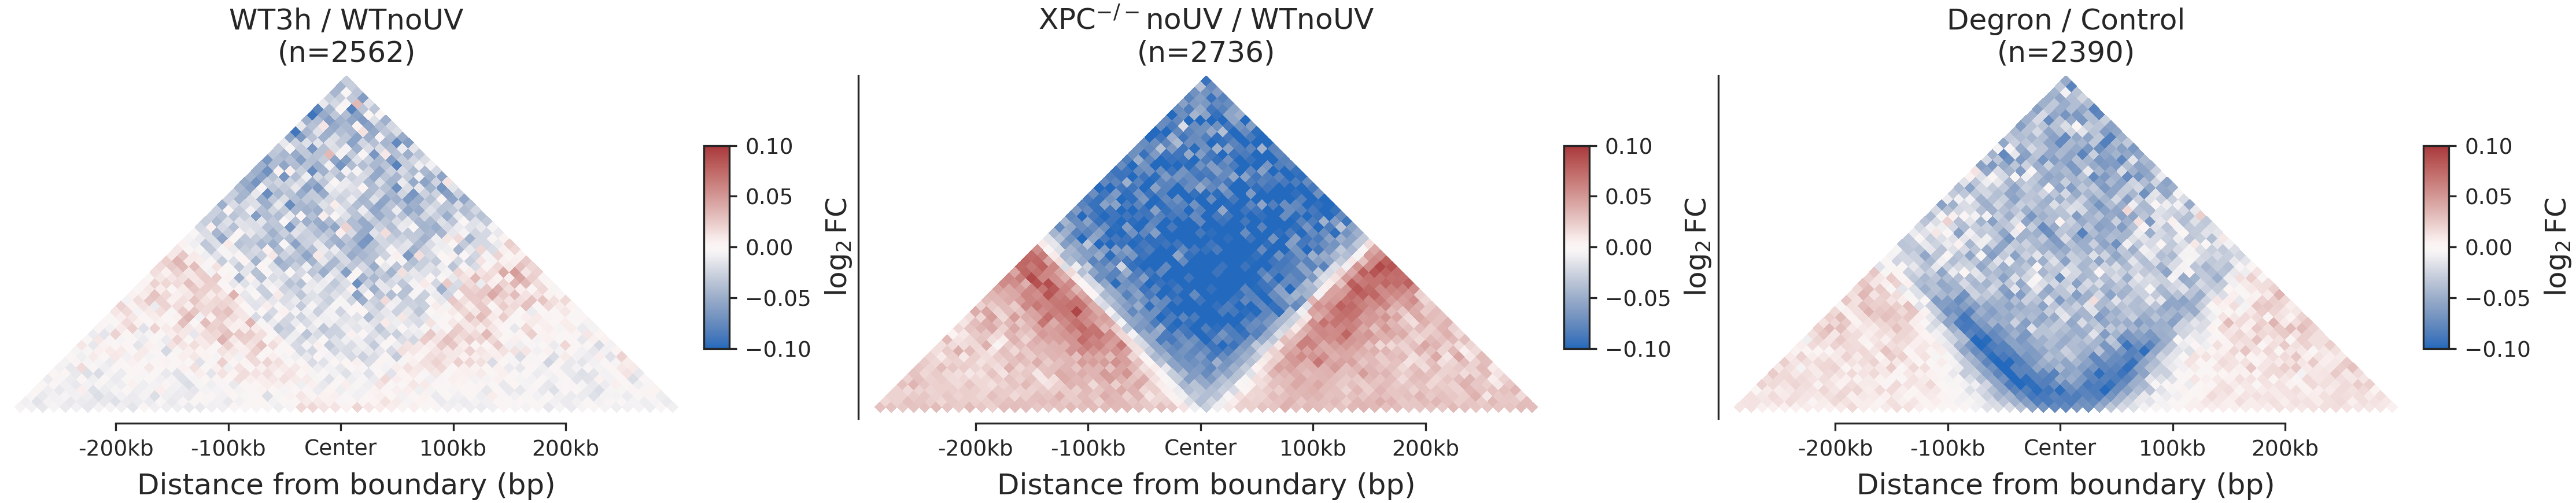

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from ggner_3d import plotting
plotting.update_rcparams()
from ggner_3d.plotting import hic_upper_triangle

fig, axs = plt.subplots(1, 3, figsize=(15,5))

base_vmin, base_vmax = -1, 1
l2fcvmin, l2fcvmax = -0.1, 0.1

label_mapping = {
    'WTnoUV vs WT3h': f'WT3h / WTnoUV\n(n={n_dict["WTnoUV vs WT3h"]})',
    'WTnoUV vs XPCnoUV': f'XPC$^{{-/-}}$noUV / WTnoUV\n(n={n_dict["WTnoUV vs XPCnoUV"]})',
    'pol2_control vs pol2_degron': f'Degron / Control\n(n={n_dict["pol2_control vs pol2_degron"]})'
}

for i, comp in enumerate(pup_dict):
    s1, s2 = comp.split(' vs ')
    pup1, pup2 = pup_dict[comp]
    pup1_mtx = pup1['data'][0]
    pup2_mtx = pup2['data'][0]
    eps = 1e-6
    l2fc = np.log2((pup2_mtx + eps) / (pup1_mtx + eps))

    hic_upper_triangle(l2fc, cmap="vlag",
    center=0,
    ax=axs[i],
    colorbar=True,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8, label=r"$\log_{2}$FC"),
    vmin=l2fcvmin, vmax=l2fcvmax
)
    axs[i].set_title(label_mapping[comp])

    for artist in axs[i].images + axs[i].collections:
        artist.set_rasterized(True)

    # add custom x-ticks
    add_x_ticks_to_apa(axs[i], l2fc, xlabel='Distance from boundary (bp)', cbar_label=r'$\log_{2}$FC', flank=flank, step_bp=100_000)

fig.tight_layout()

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig5/fig5_ab.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig5/fig5_ab.svg', dpi=300, bbox_inches='tight')